<a href="https://colab.research.google.com/github/dorian-goueytes/M1_tron_commun_stat/blob/main/SVM_impulsivit%C3%A9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import svm
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV, cross_val_score, KFold

In [ ]:
data = pd.read_csv("data.csv", sep = ';')
data = data.drop("Nom d'utilisateur", axis=1)
data = data.drop("Prénom", axis=1)
data = data.drop("Nom de famille", axis=1)
data = data.drop("Email", axis=1)
data = data.drop("Total", axis=1)


In [ ]:
scores = pd.DataFrame(columns=['main_score', 'attention', 'motor', 'nonplanning', 'Q1', 'Q2'])#,'attention','motorC','self_control','sog_comp','perseverance','cog_insta'])
for part in range(0, np.shape(data)[0]):
  main_score, attention,motor,nonplanning = 0,0,0,0
  for item in range(0, np.shape(data)[1]):
    ## Attention
    if item in np.array([5,6,9,11,20,24,26,28])-1: #attention
      if item in np.array([9,20])-1:# reversal
        if data.to_numpy()[part][item] == "Rarely/Never":
          attention +=4
        if data.to_numpy()[part][item] == "Occasionally":
          attention +=3
        if data.to_numpy()[part][item] == "Often":
          attention +=2
        if data.to_numpy()[part][item] == "Almost Always/Always":
          attention +=1
      else:
        if data.to_numpy()[part][item] == "Rarely/Never":
          attention +=1
        if data.to_numpy()[part][item] == "Occasionally":
          attention +=2
        if data.to_numpy()[part][item] == "Often":
          attention +=3
        if data.to_numpy()[part][item] == "Almost Always/Always":
          attention +=4

    ## motor
    if item in np.array([2,3,4,17,19,22,25,16,21,23,30])-1:
      if item in np.array([30])-1:# reversal
        if data.to_numpy()[part][item] == "Rarely/Never":
          motor +=4
        if data.to_numpy()[part][item] == "Occasionally":
          motor +=3
        if data.to_numpy()[part][item] == "Often":
          motor +=2
        if data.to_numpy()[part][item] == "Almost Always/Always":
          motor +=1
      else:
        if data.to_numpy()[part][item] == "Rarely/Never":
          motor +=1
        if data.to_numpy()[part][item] == "Occasionally":
          motor +=2
        if data.to_numpy()[part][item] == "Often":
          motor +=3
        if data.to_numpy()[part][item] == "Almost Always/Always":
          motor +=4

    ## nonplanning
    if item in np.array([1,7,8,12,13,14,10,15,18,27,29])-1:
      if item in np.array([1,7,8,12,13,10,15,29])-1:# reversal
        if data.to_numpy()[part][item] == "Rarely/Never":
          nonplanning +=4
        if data.to_numpy()[part][item] == "Occasionally":
          nonplanning +=3
        if data.to_numpy()[part][item] == "Often":
          nonplanning +=2
        if data.to_numpy()[part][item] == "Almost Always/Always":
          nonplanning +=1
      else:
        if data.to_numpy()[part][item] == "Rarely/Never":
          nonplanning +=1
        if data.to_numpy()[part][item] == "Occasionally":
          nonplanning +=2
        if data.to_numpy()[part][item] == "Often":
          nonplanning +=3
        if data.to_numpy()[part][item] == "Almost Always/Always":
          nonplanning +=4

    ### Main score
    if data.to_numpy()[part][item] == "Rarely/Never":
      main_score +=1
    if data.to_numpy()[part][item] == "Occasionally":
      main_score +=2
    if data.to_numpy()[part][item] == "Often":
      main_score +=3
    if data.to_numpy()[part][item] == "Almost Always/Always":
      main_score +=4

    if item == 30:
      if data.to_numpy()[part][item] == "Obtenir un paquet de chocolats à la fin du cours d'aujourd'hui":
        Q1 = 1
      else:
        Q1 = -1
    if item == 31:
      if data.to_numpy()[part][item] == "Obtenir un paquet de chocolats dans 12 mois":
        Q2 = 1
      else:
        Q2 = -1



  scores.loc[part] = [main_score, attention, motor, nonplanning, Q1, Q2]
print(scores)


   main_score  attention  motor  nonplanning  Q1  Q2
0          62         20     24           21   1   1
1          77         22     30           34  -1  -1
2           0          0      0            0  -1  -1


### Do not run with real data

In [ ]:
#for i in range(0,200):
#  scores.loc[i] = [np.random.normal(scores['main_score'][0], scores['main_score'][0]/6),
#                      np.random.normal(scores['attention'][0], scores['attention'][0]/6),
#                      np.random.normal(scores['motor'][0], scores['motor'][0]/6),
#                      np.random.normal(scores['nonplanning'][0], scores['nonplanning'][0]/6),
#                      np.random.choice([-1,1]), np.random.choice([-1,1])]
#print(scores)

/tmp/ipykernel_865/631632291.py:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '66.86307543279177' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  scores.loc[i] = [np.random.normal(scores['main_score'][0], scores['main_score'][0]/6),
/tmp/ipykernel_865/631632291.py:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '23.524008531006192' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  scores.loc[i] = [np.random.normal(scores['main_score'][0], scores['main_score'][0]/6),
/tmp/ipykernel_865/631632291.py:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '22.462901859853396' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  scores.l

     main_score  attention      motor  nonplanning   Q1   Q2
0     66.863075  23.524009  22.462902    24.956043  1.0  1.0
1     59.392478  27.080508  22.826663    31.814935 -1.0 -1.0
2     65.493594  22.219770  22.187835    25.962467 -1.0 -1.0
3     85.884277  17.146100  23.900679    17.937272  1.0 -1.0
4     73.792750  22.692825  18.346036    17.212274  1.0  1.0
..          ...        ...        ...          ...  ...  ...
195   50.929357  29.575850  27.859727    25.944592  1.0 -1.0
196   65.840899  29.405200  18.764798    25.466378  1.0 -1.0
197   80.227325  17.220573  19.505898    27.418624 -1.0 -1.0
198   66.088366  25.686495  28.992537    27.308325 -1.0 -1.0
199   68.287973  17.377615  18.667187    30.175448 -1.0  1.0

[200 rows x 6 columns]


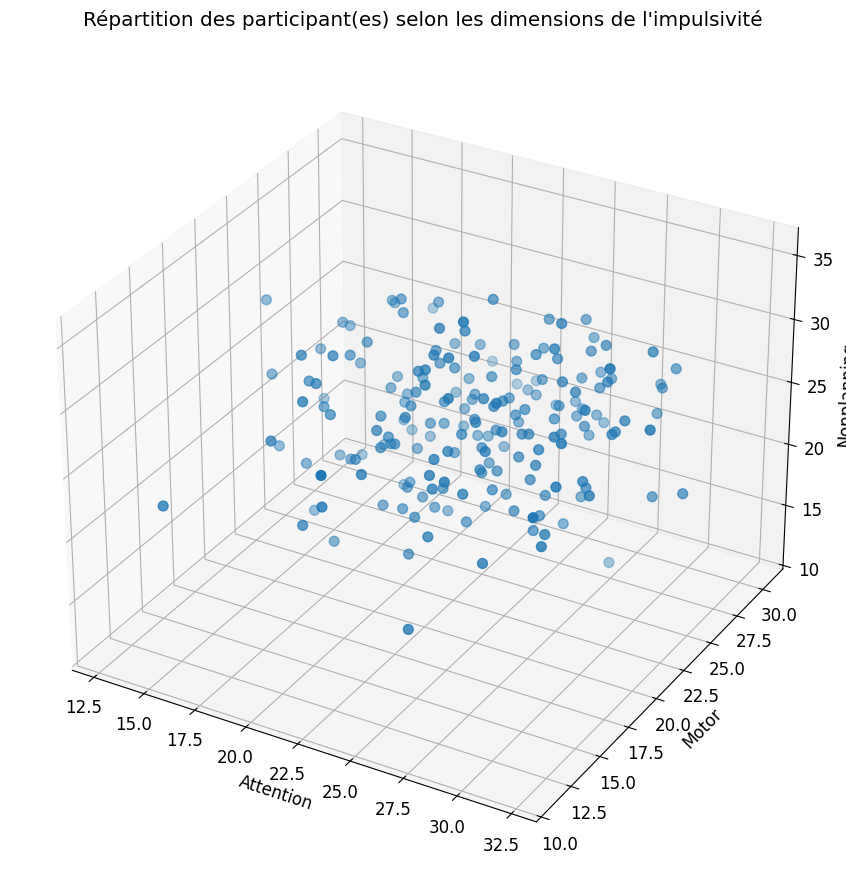

In [ ]:
fig = plt.figure(figsize=(9, 9))
plt.suptitle("Répartition des participant(es) selon les dimensions de l'impulsivité")
plt.rcParams.update({'font.size': 12})
ax = fig.add_subplot(projection='3d')

ax.scatter(scores['attention'], scores['motor'], scores['nonplanning'], s =  50)
ax.set_xlabel('Attention')
ax.set_ylabel('Motor')
ax.set_zlabel('Nonplanning')
plt.tight_layout()
plt.show()

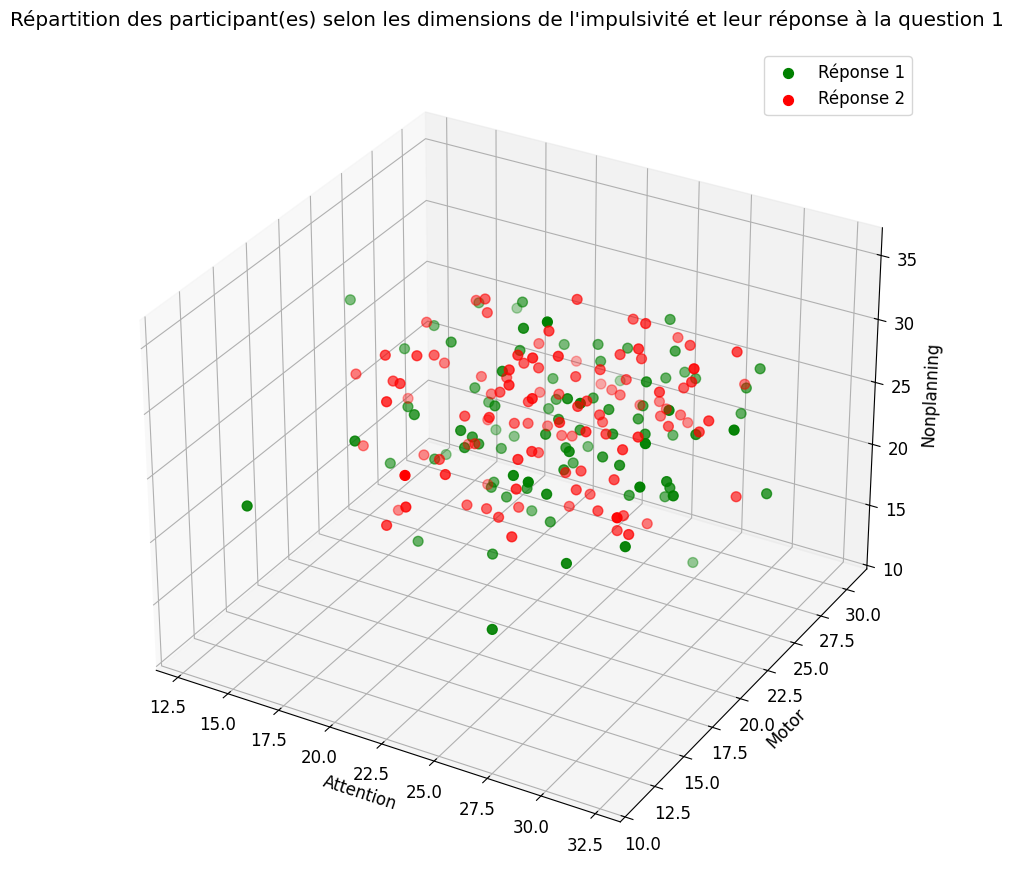

In [ ]:
fig = plt.figure(figsize=(9, 9))
plt.rcParams.update({'font.size': 12})
ax = fig.add_subplot(projection='3d')
plt.suptitle("Répartition des participant(es) selon les dimensions de l'impulsivité et leur réponse à la question 1")

ax.scatter(scores['attention'].loc[np.where(scores['Q1'] ==1)[0]], scores['motor'].loc[np.where(scores['Q1'] ==1)[0]], scores['nonplanning'].loc[np.where(scores['Q1'] ==1)[0]], color= 'g', s = 50, label = 'Réponse 1')
ax.scatter(scores['attention'].loc[np.where(scores['Q1'] ==-1)[0]], scores['motor'].loc[np.where(scores['Q1'] ==-1)[0]], scores['nonplanning'].loc[np.where(scores['Q1'] ==-1)[0]], color= 'r', s = 50, label = 'Réponse 2')


ax.set_xlabel('Attention')
ax.set_ylabel('Motor')
ax.set_zlabel('Nonplanning')
plt.legend()
plt.tight_layout()
plt.show()

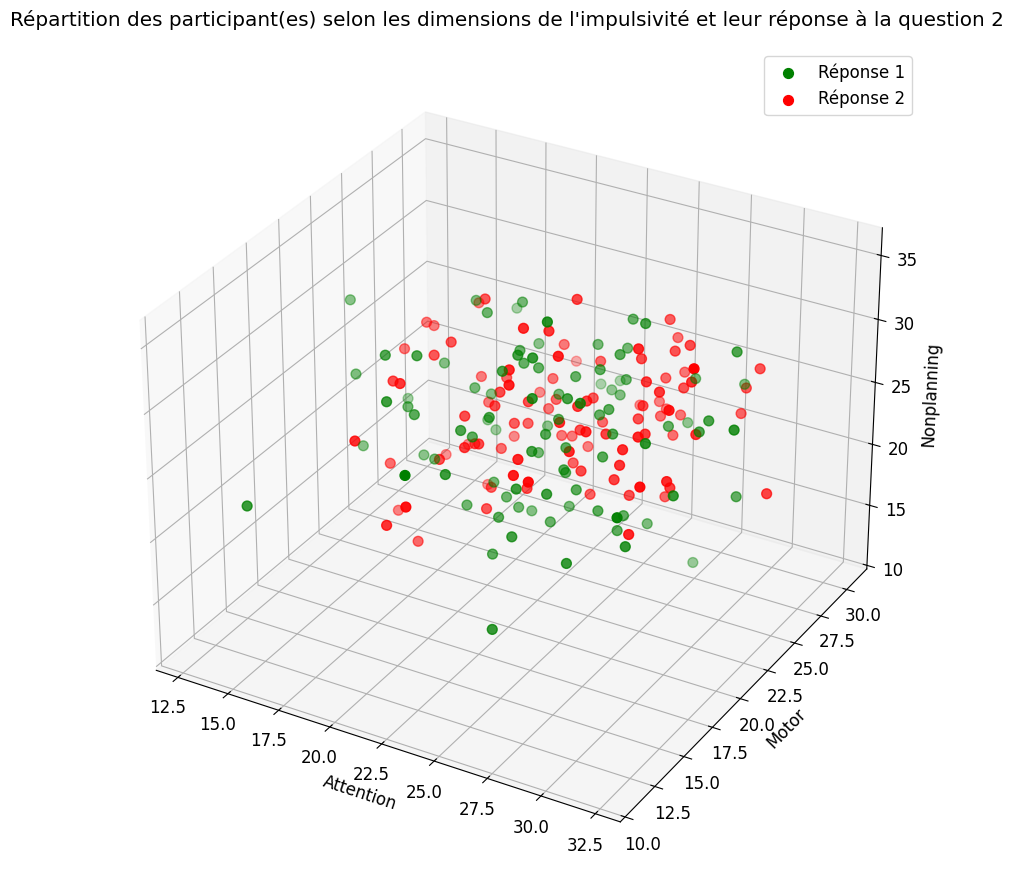

In [ ]:
fig = plt.figure(figsize=(9, 9))
plt.rcParams.update({'font.size': 12})
ax = fig.add_subplot(projection='3d')
plt.suptitle("Répartition des participant(es) selon les dimensions de l'impulsivité et leur réponse à la question 2")

ax.scatter(scores['attention'].loc[np.where(scores['Q2'] ==1)[0]], scores['motor'].loc[np.where(scores['Q2'] ==1)[0]], scores['nonplanning'].loc[np.where(scores['Q2'] ==1)[0]], color= 'g', s = 50, label = 'Réponse 1')
ax.scatter(scores['attention'].loc[np.where(scores['Q2'] ==-1)[0]], scores['motor'].loc[np.where(scores['Q2'] ==-1)[0]], scores['nonplanning'].loc[np.where(scores['Q2'] ==-1)[0]], color= 'r', s = 50, label = 'Réponse 2')


ax.set_xlabel('Attention')
ax.set_ylabel('Motor')
ax.set_zlabel('Nonplanning')
plt.legend()
plt.tight_layout()
plt.show()

[60.86483296731595, 70.7405747637417]


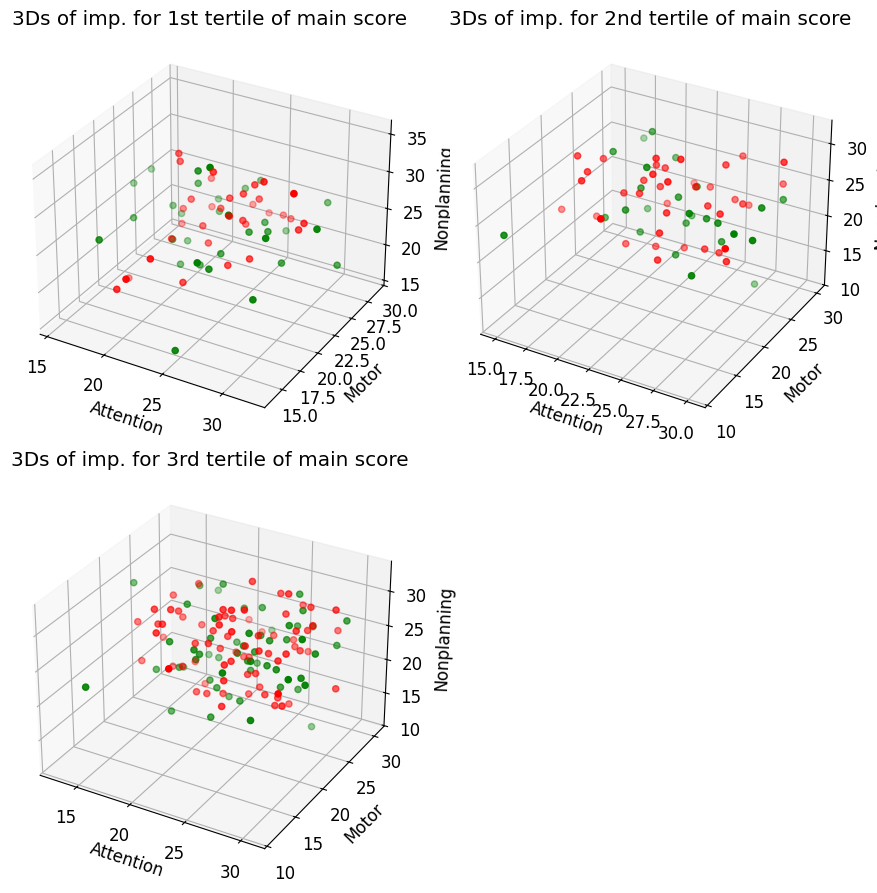

In [ ]:
tertiles = scores['main_score'].quantile([1/3,2/3]).tolist()
print(tertiles)
plt.rcParams.update({'font.size': 12})

data_first_tertile = scores.loc[np.where(scores['main_score']<=tertiles[0])[0]]
data_first_tertile = data_first_tertile.reset_index()
data_second_tertile = scores.loc[np.where(np.logical_and(scores['main_score']>tertiles[0], scores['main_score']<=tertiles[1]))[0]]
data_second_tertile = data_second_tertile.reset_index()
data_third_tertile = scores.loc[np.where(scores['main_score']>tertiles[0])[0]]
data_third_tertile = data_third_tertile.reset_index()


fig = plt.figure(figsize=(9, 9))
ax = fig.add_subplot(221,projection='3d')
ax.scatter(data_first_tertile['attention'].loc[np.where(data_first_tertile['Q1'] ==1)[0]], data_first_tertile['motor'].loc[np.where(data_first_tertile['Q1'] ==1)[0]], data_first_tertile['nonplanning'].loc[np.where(data_first_tertile['Q1'] ==1)[0]], color= 'g')
ax.scatter(data_first_tertile['attention'].loc[np.where(data_first_tertile['Q1'] ==-1)[0]], data_first_tertile['motor'].loc[np.where(data_first_tertile['Q1'] ==-1)[0]], data_first_tertile['nonplanning'].loc[np.where(data_first_tertile['Q1'] ==-1)[0]], color= 'r')
ax.set_xlabel('Attention')
ax.set_ylabel('Motor')
ax.set_zlabel('Nonplanning')
ax.set_title('3Ds of imp. for 1st tertile of main score')
#plt.show()

#fig = plt.figure(figsize=(6, 6))
ax1 = fig.add_subplot(222,projection='3d')
ax1.scatter(data_second_tertile['attention'].loc[np.where(data_second_tertile['Q1'] ==1)[0]], data_second_tertile['motor'].loc[np.where(data_second_tertile['Q1'] ==1)[0]], data_second_tertile['nonplanning'].loc[np.where(data_second_tertile['Q1'] ==1)[0]], color= 'g')
ax1.scatter(data_second_tertile['attention'].loc[np.where(data_second_tertile['Q1'] ==-1)[0]], data_second_tertile['motor'].loc[np.where(data_second_tertile['Q1'] ==-1)[0]], data_second_tertile['nonplanning'].loc[np.where(data_second_tertile['Q1'] ==-1)[0]], color= 'r')
ax1.set_xlabel('Attention')
ax1.set_ylabel('Motor')
ax1.set_zlabel('Nonplanning')
ax1.set_title('3Ds of imp. for 2nd tertile of main score')
#plt.tight_layout()
#plt.show()

#fig = plt.figure(figsize=(6, 6))
ax2 = fig.add_subplot(223,projection='3d')
ax2.scatter(data_third_tertile['attention'].loc[np.where(data_third_tertile['Q1'] ==1)[0]], data_third_tertile['motor'].loc[np.where(data_third_tertile['Q1'] ==1)[0]], data_third_tertile['nonplanning'].loc[np.where(data_third_tertile['Q1'] ==1)[0]], color= 'g')
ax2.scatter(data_third_tertile['attention'].loc[np.where(data_third_tertile['Q1'] ==-1)[0]], data_third_tertile['motor'].loc[np.where(data_third_tertile['Q1'] ==-1)[0]], data_third_tertile['nonplanning'].loc[np.where(data_third_tertile['Q1'] ==-1)[0]], color= 'r')
ax2.set_xlabel('Attention')
ax2.set_ylabel('Motor')
ax2.set_zlabel('Nonplanning')
ax2.set_title('3Ds of imp. for 3rd tertile of main score')
plt.tight_layout()
plt.show()

### SVM Simple

In [ ]:
clf = svm.SVC(kernel = 'linear')
X  = scores[['attention', 'motor', 'nonplanning']].to_numpy()
y = scores['Q1'].to_numpy()
clf.fit(X[0:198], y[0:198])

[-1. -1. -1. -1.]


In [ ]:
print(clf.predict(X[0:4]))
print(y[0:3])

[-1. -1. -1. -1.]
[ 1. -1. -1.]


#### Plane visualization

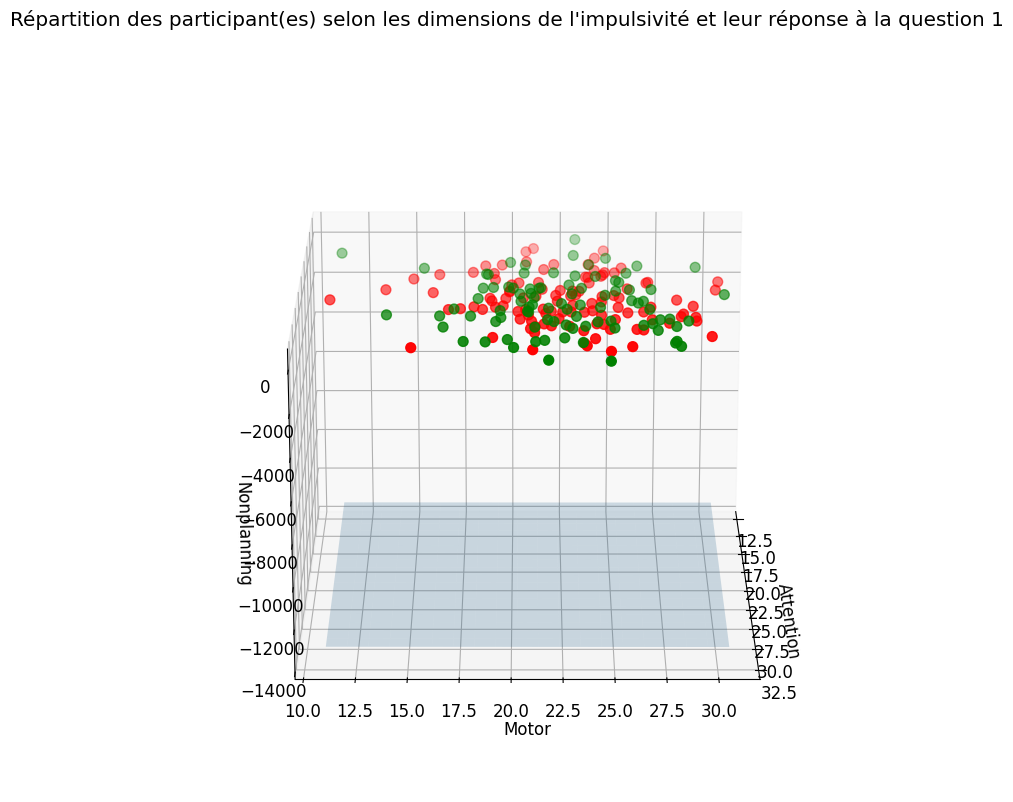

In [ ]:
fig = plt.figure(figsize=(9, 9))
plt.rcParams.update({'font.size': 12})
ax = fig.add_subplot(projection='3d')
plt.suptitle("Répartition des participant(es) selon les dimensions de l'impulsivité et leur réponse à la question 1")

ax.scatter(scores['attention'].loc[np.where(scores['Q1'] ==1)[0]], scores['motor'].loc[np.where(scores['Q1'] ==1)[0]], scores['nonplanning'].loc[np.where(scores['Q1'] ==1)[0]], color= 'g', s = 50, label = 'Réponse 1')
ax.scatter(scores['attention'].loc[np.where(scores['Q1'] ==-1)[0]], scores['motor'].loc[np.where(scores['Q1'] ==-1)[0]], scores['nonplanning'].loc[np.where(scores['Q1'] ==-1)[0]], color= 'r', s = 50, label = 'Réponse 2')


ax.set_xlabel('Attention')
ax.set_ylabel('Motor')
ax.set_zlabel('Nonplanning')



# Extract plane parameters
w = clf.coef_[0]
b = clf.intercept_[0]

# Create grid
xx, yy = np.meshgrid(
    np.linspace(X[:,0].min(), X[:,0].max(), 20),
    np.linspace(X[:,1].min(), X[:,1].max(), 20)
)

# Compute z for the plane
zz = (-w[0]*xx - w[1]*yy - b) / w[2]

# Plot plane
ax.plot_surface(xx, yy, zz, alpha=0.2)

ax.view_init(azim=0, elev=20)

plt.show()

### Correlation matrices

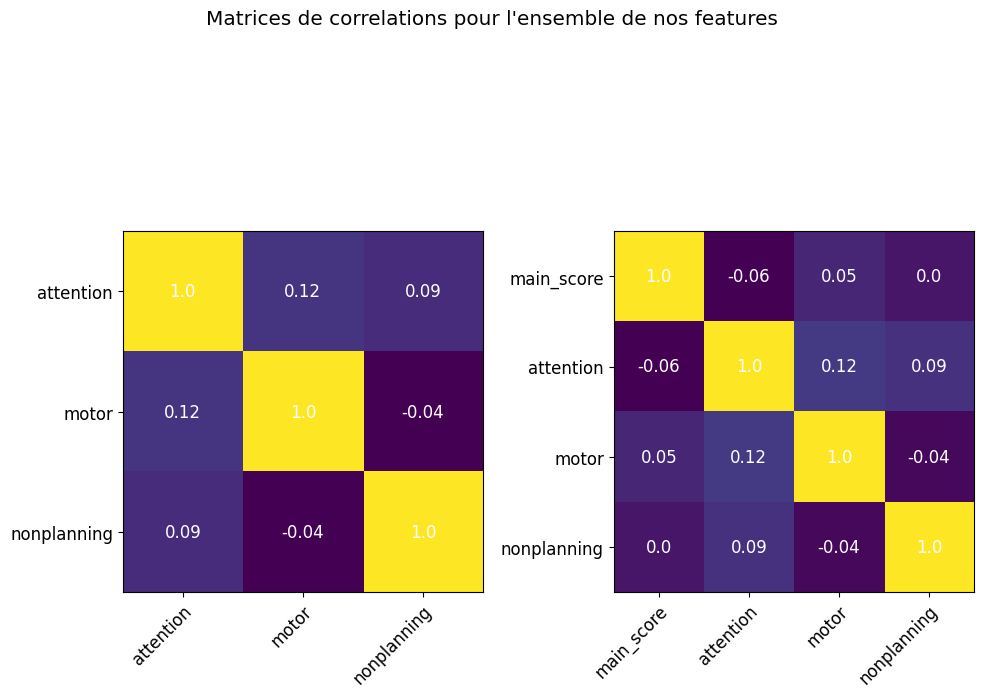

In [ ]:
fig, (ax1, ax2) = plt.subplots(1,2, figsize = (10,8))

cor1 = scores[['attention', 'motor', 'nonplanning']].corr()
cor2 = scores[['main_score', 'attention', 'motor', 'nonplanning']].corr()
im1 = ax1.imshow(cor1)

# Loop over data dimensions and create text annotations.
for i in range(np.shape(cor1)[0]):
    for j in range(np.shape(cor1)[1]):
        text = ax1.text(j, i, np.round(cor1.to_numpy()[i, j],2), ha="center", va="center", color="w")

# Show all ticks and label them with the respective list entries
ax1.set_xticks(range(len(cor1.keys())), labels=cor1.keys(),
              rotation=45, ha="right", rotation_mode="anchor")
ax1.set_yticks(range(len(cor1.keys())), labels=cor1.keys())

im2 = ax2.imshow(cor2)
# Loop over data dimensions and create text annotations.
for i in range(np.shape(cor2)[0]):
    for j in range(np.shape(cor2)[1]):
        text = ax2.text(j, i, np.round(cor2.to_numpy()[i, j],2), ha="center", va="center", color="w")
# Show all ticks and label them with the respective list entries
ax2.set_xticks(range(len(cor2.keys())), labels=cor2.keys(),
              rotation=45, ha="right", rotation_mode="anchor")
ax2.set_yticks(range(len(cor2.keys())), labels=cor2.keys())
plt.suptitle("Matrices de correlations pour l'ensemble de nos features")
plt.tight_layout()
plt.show()

### SVM + Kfold

In [ ]:
kf = KFold(n_splits=10)
kf.get_n_splits()
global_acc = []
KFold(n_splits=2, random_state=None, shuffle=False)
for i, (train_index, test_index) in enumerate(kf.split(X)):
    print(f"Fold {i}:")
    clf.fit(X[train_index], y[train_index])
    test = clf.predict(X[test_index])
    acc = sum(x == y for x, y in zip(test, y[test_index])) / min(len(test), len(y[test_index]))
    global_acc.append(acc)
    print('Pourcentage de prédictions correctes : '+str(acc*100)+'%')
    print()
print('Performance moyenne : '+str(np.mean(global_acc))+'%')


Fold 0:
Pourcentage de prédictions correctes : 45.0%

Fold 1:
Pourcentage de prédictions correctes : 60.0%

Fold 2:
Pourcentage de prédictions correctes : 60.0%

Fold 3:
Pourcentage de prédictions correctes : 50.0%

Fold 4:
Pourcentage de prédictions correctes : 40.0%

Fold 5:
Pourcentage de prédictions correctes : 60.0%

Fold 6:
Pourcentage de prédictions correctes : 60.0%

Fold 7:
Pourcentage de prédictions correctes : 50.0%

Fold 8:
Pourcentage de prédictions correctes : 65.0%

Fold 9:
Pourcentage de prédictions correctes : 55.00000000000001%

Performance moyenne : 0.545%


### SVM + gridsearch

In [ ]:


# Parameter grid
param_grid = {'kernel': ['linear', 'rbf'], 'C': np.linspace(0.1, 10, 10)}

# Base classifier
svc = svm.SVC()

# Inner CV: grid search for hyperparameters
grid_search = GridSearchCV(estimator=svc, param_grid=param_grid, cv=3)
#print("Best parameters:", grid_search.best_params_)

# Outer CV: evaluate generalization performance
outer_cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Perform nested cross-validation
nested_scores = cross_val_score(grid_search, X, y, cv=outer_cv, scoring='accuracy')

print("Nested CV accuracy scores for each outer fold:", nested_scores)
print("Mean nested CV accuracy:", nested_scores.mean())
print(nested_scores.)

Nested CV accuracy scores for each outer fold: [0.625 0.425 0.425 0.45  0.65 ]
Mean nested CV accuracy: 0.515


In [ ]:
print(nested_scores.cv_results_)

AttributeError: 'numpy.ndarray' object has no attribute 'cv_results_'

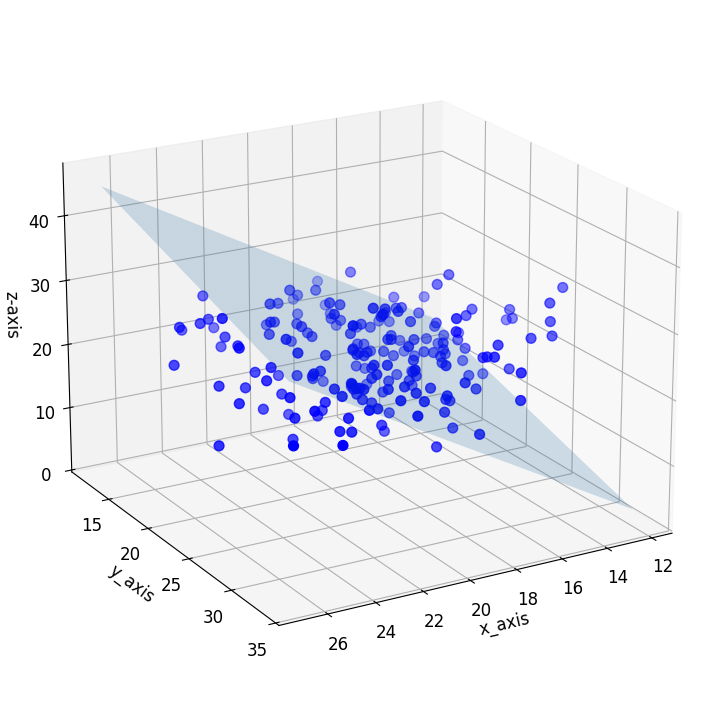

In [ ]:
fig = plt.figure(figsize=(9, 9))
plt.rcParams.update({'font.size': 12})
ax = fig.add_subplot(projection='3d')

ax.scatter(scores['attention'].loc[np.where(scores['Q1'] ==1)[0]], scores['motor'].loc[np.where(scores['Q1'] ==1)[0]], scores['nonplanning'].loc[np.where(scores['Q1'] ==1)[0]], color= 'b', s = 50)
ax.scatter(scores['attention'].loc[np.where(scores['Q1'] ==-1)[0]], scores['motor'].loc[np.where(scores['Q1'] ==-1)[0]], scores['nonplanning'].loc[np.where(scores['Q1'] ==-1)[0]], color= 'b', s = 50)


ax.set_xlabel('x_axis')
ax.set_ylabel('y_axis')
ax.set_zlabel('z-axis')



# Extract plane parameters
w = clf.coef_[0]
b = clf.intercept_[0]

# Create grid
xx, yy = np.meshgrid(
    np.linspace(X[:,0].min(), X[:,0].max(), 20),
    np.linspace(X[:,1].min(), X[:,1].max(), 20)
)

# Compute z for the plane
zz = (-w[0]*xx - w[1]*yy - b) / w[2]

# Plot plane
ax.plot_surface(xx, yy, zz, alpha=0.2)

ax.view_init(azim=60, elev=20)

plt.show()

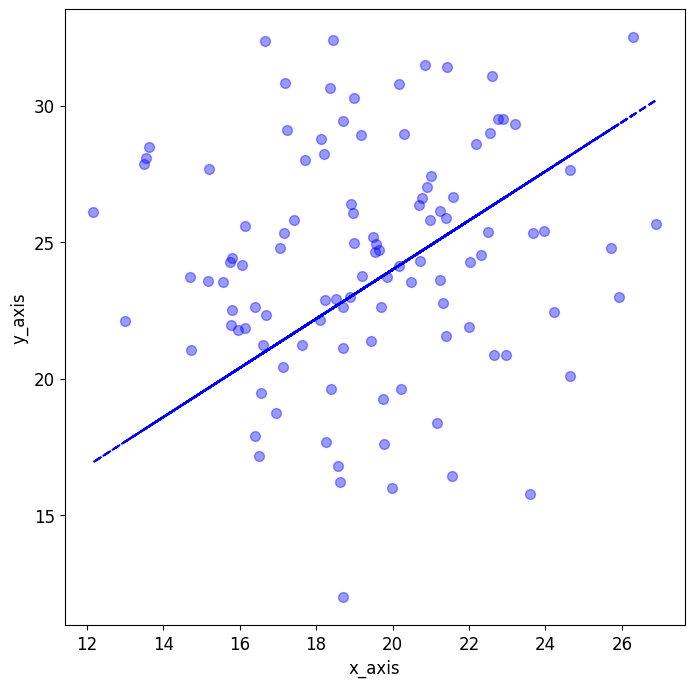

In [ ]:
fig = plt.figure(figsize=(8, 8))
plt.rcParams.update({'font.size': 12})


plt.scatter(scores['attention'].loc[np.where(scores['Q1'] ==1)[0]], scores['motor'].loc[np.where(scores['Q1'] ==1)[0]], color= 'b', s = 50, alpha = 0.4)

temp = []
for i in scores['attention'].loc[np.where(scores['Q1'] ==1)[0]].to_numpy():
  temp.append(i*0.9 +6)

plt.plot(scores['attention'].loc[np.where(scores['Q1'] ==1)[0]], temp, color = 'b', linestyle = '--')

plt.xlabel('x_axis')
plt.ylabel('y_axis')



plt.show()